# Project title:   Lung Cancer Detection from CT Scan Images using CNN
This notebook demonstrates data preprocessing, visualization, and classification of CT scan images using Convolutional Neural Networks (CNNs) on the IQ-OTHNCCD Lung Cancer Dataset.


In [ ]:
!pip install kaggle

In [ ]:
!mkdir ~/.kaggle

In [ ]:
!cp kaggle.json ~/.kaggle/


In [ ]:
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download adityamahimkar/iqothnccd-lung-cancer-dataset

Dataset URL: https://www.kaggle.com/datasets/adityamahimkar/iqothnccd-lung-cancer-dataset
License(s): copyright-authors
 54% 108M/199M [00:00<00:00, 1.13GB/s]
100% 199M/199M [00:00<00:00, 610MB/s] 


In [ ]:
!unzip iqothnccd-lung-cancer-dataset.zip

Archive:  iqothnccd-lung-cancer-dataset.zip
  inflating: Test cases/000001_03_01_088.png  
  inflating: Test cases/000017_02_01_016.png  
  inflating: Test cases/000019_01_01_021.png  
  inflating: Test cases/000019_02_01_025.png  
  inflating: Test cases/000019_03_01_025.png  
  inflating: Test cases/000020_01_01_066.png  
  inflating: Test cases/000020_02_01_062.png  
  inflating: Test cases/000020_03_01_134.png  
  inflating: Test cases/000020_03_01_166.png  
  inflating: Test cases/000020_03_01_212.png  
  inflating: Test cases/000020_04_01_116.png  
  inflating: Test cases/000020_04_01_143.png  
  inflating: Test cases/000020_04_01_159.png  
  inflating: Test cases/000021_01_01_016.png  
  inflating: Test cases/000021_02_01_068.png  
  inflating: Test cases/000021_03_01_012.png  
  inflating: Test cases/000021_03_01_017.png  
  inflating: Test cases/000021_04_01_090.png  
  inflating: Test cases/000027_01_01_113.png  
  inflating: Test cases/000027_02_01_105.png  
  inflating: Tes

In [ ]:
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns


# Import necessary libraries
from PIL import Image
import os
from IPython.display import display # To display images in the notebook

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam


##  Load and Explore the Dataset
We begin by organizing the dataset and inspecting its structure. The dataset contains CT scan images categorized into three classes:
- **Normal**
- **Benign**
- **Malignant**

In [ ]:
# Assuming the three class folders are directly within 'The IQ-OTHNCCD lung cancer dataset'
base_path = 'The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset' # Double check this path based on your 'ls' output

# Define the names of your class folders
classes = ['Bengin cases', 'Malignant cases', 'Normal cases'] # Corrected spelling based on common terminology

# Dictionary to store image paths and their corresponding labels
image_data = {'image_path': [], 'label': []}

# Loop through each class folder
for class_name in classes:
    class_directory = os.path.join(base_path, class_name)

    # Check if the class directory exists
    if os.path.exists(class_directory):
        print(f"Processing images in: {class_directory}")

        # List all files in the directory
        image_files = [f for f in os.listdir(class_directory) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        print(f"Found {len(image_files)} image files in {class_name}")

        # Store image paths and labels
        for image_file in image_files:
            image_path = os.path.join(class_directory, image_file)
            image_data['image_path'].append(image_path)
            image_data['label'].append(class_name) # Use the folder name as the label

    else:
        print(f"Class directory not found: {class_directory}")

Processing images in: The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset/Bengin cases
Found 120 image files in Bengin cases
Processing images in: The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset/Malignant cases
Found 561 image files in Malignant cases
Processing images in: The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset/Normal cases
Found 416 image files in Normal cases


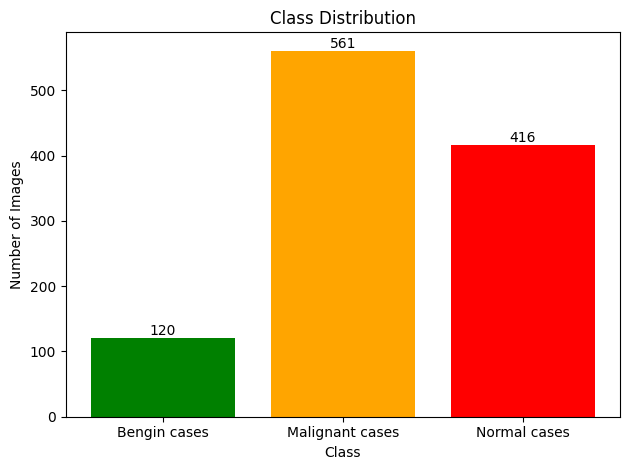

In [ ]:
# Count number of images in each class
counts = [len(os.listdir(os.path.join(base_path, cls))) for cls in classes]

# Create bar plot
bars = plt.bar(classes, counts, color=['green', 'orange', 'red'])

# Add count numbers above each bar
plt.bar_label(bars)

# Titles and labels
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Images')

# Show plot
plt.tight_layout()
plt.show()


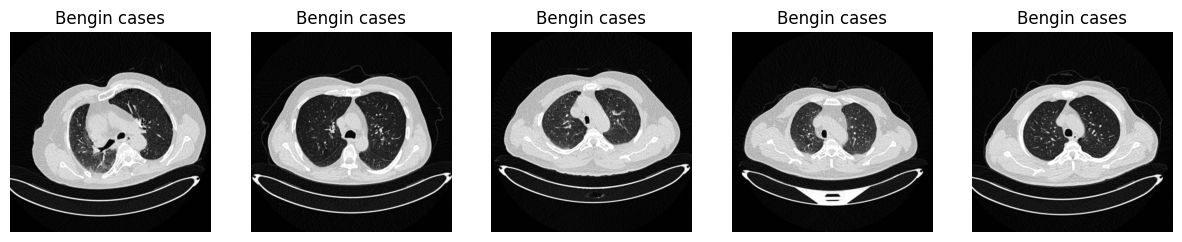

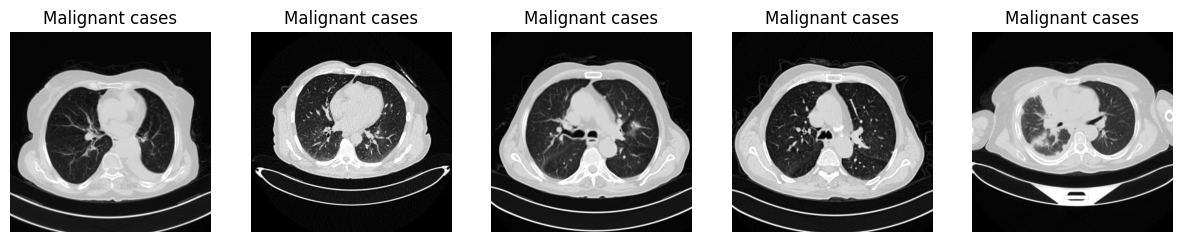

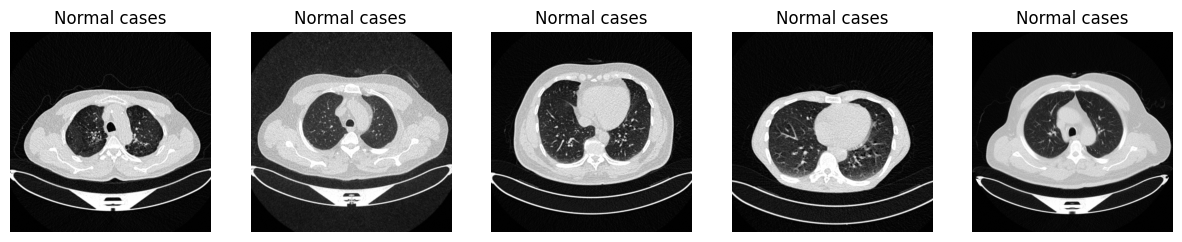

In [ ]:
def plot_sample_images(class_name, num_images=5):
    folder = os.path.join(base_path, class_name)
    images = os.listdir(folder)[:num_images]
    plt.figure(figsize=(15, 3))
    for i, img_name in enumerate(images):
        img_path = os.path.join(folder, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        plt.subplot(1, num_images, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(f"{class_name}")
        plt.axis('off')
    plt.show()

for cls in classes:
    plot_sample_images(cls)


In [ ]:

image_shapes = []
for cls in classes:
    folder = os.path.join(base_path, cls)
    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        image_shapes.append(img.shape)

unique_shapes = set(image_shapes)
print(f"Unique image dimensions: {unique_shapes}")


Unique image dimensions: {(512, 512), (404, 511), (512, 801), (512, 623), (331, 506)}


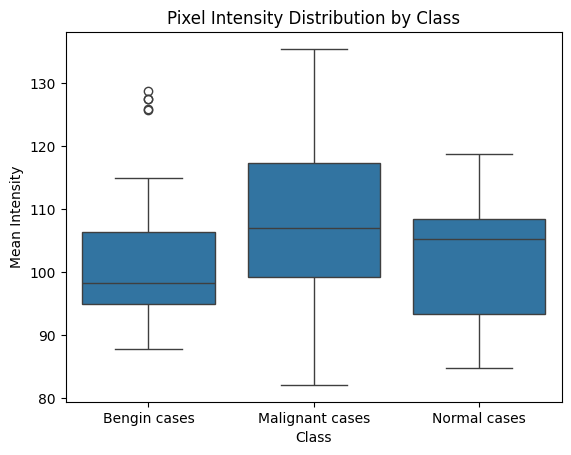

In [ ]:
data = []
for cls in classes:
    folder = os.path.join(base_path, cls)
    for img_name in os.listdir(folder)[:50]:  # Sample 50 images per class
        img_path = os.path.join(folder, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        mean_intensity = np.mean(img)
        data.append({'Class': cls, 'Mean Intensity': mean_intensity})

df = pd.DataFrame(data)
sns.boxplot(x='Class', y='Mean Intensity', data=df)
plt.title('Pixel Intensity Distribution by Class')
plt.show()


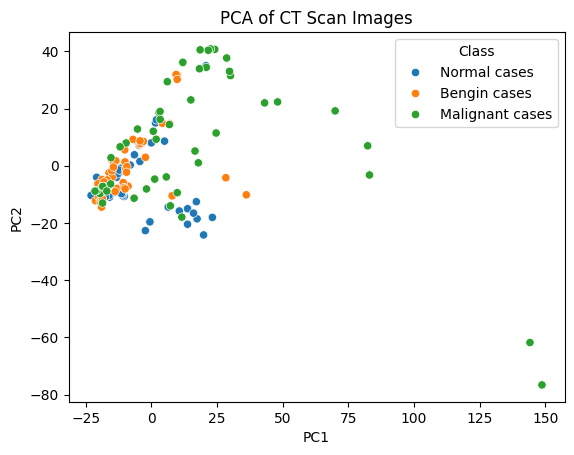

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Flatten images and create dataset
X = []
y = []
for cls in classes:
    folder = os.path.join(base_path, cls)
    for img_name in os.listdir(folder)[:50]:  # Sample 50 images per class
        img_path = os.path.join(folder, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img_resized = cv2.resize(img, (64, 64))
        X.append(img_resized.flatten())
        y.append(cls)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


df_pca = pd.DataFrame({'PC1': X_pca[:, 0], 'PC2': X_pca[:, 1], 'Class': y})

sns.scatterplot(x='PC1', y='PC2', hue='Class', data=df_pca)

plt.title('PCA of CT Scan Images')

plt.show()


In [ ]:
import cv2
from PIL import Image

img_pil = Image.open('The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset/Normal cases/Normal case (255).jpg')
print('Pillow: ', img_pil.mode, img_pil.size)

img = cv2.imread('The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset/Normal cases/Normal case (255).jpg', cv2.IMREAD_UNCHANGED)
print('OpenCV: ', img.shape)

Pillow:  RGB (512, 512)
OpenCV:  (512, 512, 3)




### Each image is a `.jpg` file and saved in RGB format.


##  Data Preprocessing
In this step, we:
- Read each image in **RGB** format.
- Resize all images to a fixed size (`128x128`) for model compatibility.
- Normalize pixel values to the [0, 1] range.
- Encode class labels and split the dataset into training and testing sets.


In [ ]:
IMG_SIZE = 128
data = []
labels = []

for cls in classes:
    folder = os.path.join(base_path, cls)
    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            data.append(img / 255.0)
            labels.append(cls)

X = np.array(data)

# X = np.array(data).reshape(-1, IMG_SIZE, IMG_SIZE, 1)
le = LabelEncoder()
y = to_categorical(le.fit_transform(labels))


In [ ]:
print(X.shape)
print(y.shape)

(1097, 128, 128, 3)
(1097, 3)


In [ ]:
print(X[1])

[[[0.14901961]
  [0.14901961]
  [0.14901961]
  ...
  [0.14901961]
  [0.14901961]
  [0.14901961]]

 [[0.14901961]
  [0.14901961]
  [0.14901961]
  ...
  [0.14901961]
  [0.14901961]
  [0.14901961]]

 [[0.14901961]
  [0.14901961]
  [0.14901961]
  ...
  [0.14901961]
  [0.14901961]
  [0.14901961]]

 ...

 [[0.14901961]
  [0.14901961]
  [0.14901961]
  ...
  [0.14901961]
  [0.14901961]
  [0.14901961]]

 [[0.14901961]
  [0.14901961]
  [0.14901961]
  ...
  [0.14901961]
  [0.14901961]
  [0.14901961]]

 [[0.14901961]
  [0.14901961]
  [0.14901961]
  ...
  [0.14901961]
  [0.14901961]
  [0.14901961]]]


In [ ]:
y[0]

array([0., 0., 1.])

##  Building a Convolutional Neural Network (CNN)
We define a simple CNN architecture using:
- Two convolutional layers followed by max-pooling.
- A fully connected dense layer with dropout.
- A softmax output layer for multi-class classification (3 classes).


In [ ]:

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


##  Model Training
The CNN is compiled using the **Adam** optimizer and trained for a fixed number of epochs(10) . The model learns to distinguish between Normal, Benign, and Malignant CT scans.


In [ ]:
# Compile model
model.compile(optimizer=Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Train model
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test), batch_size=32)

Epoch 1/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 28s 848ms/step - accuracy: 0.5254 - loss: 1.6810 - val_accuracy: 0.5773 - val_loss: 0.8138
Epoch 2/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 39s 812ms/step - accuracy: 0.6928 - loss: 0.7221 - val_accuracy: 0.8455 - val_loss: 0.4430
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 42s 838ms/step - accuracy: 0.8391 - loss: 0.4049 - val_accuracy: 0.9545 - val_loss: 0.2023
Epoch 4/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 40s 809ms/step - accuracy: 0.9082 - loss: 0.2110 - val_accuracy: 0.9500 - val_loss: 0.1592
Epoch 5/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 40s 758ms/step - accuracy: 0.9556 - loss: 0.1547 - val_accuracy: 1.0000 - val_loss: 0.0465
Epoch 6/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 41s 788ms/step - accuracy: 0.9874 - loss: 0.0607 - val_accuracy: 1.0000 - val_loss: 0.0246
Epoch 7/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.9947 - loss: 0.0363 - val_accuracy: 0.9909 - val_loss: 0.0246
Epoch 8/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.9786 - loss: 0.0618 - val_accuracy: 

##  Model Evaluation & Visualization
We evaluate the model on the test set using:
- **Classification Report**
- **Confusion Matrix**
- **Accuracy and Loss Curves**

These help us understand how well the model is performing and identify potential improvements.


In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.4f}")


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 184ms/step - accuracy: 0.9952 - loss: 0.0120
Test Accuracy: 0.9955


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 287ms/step


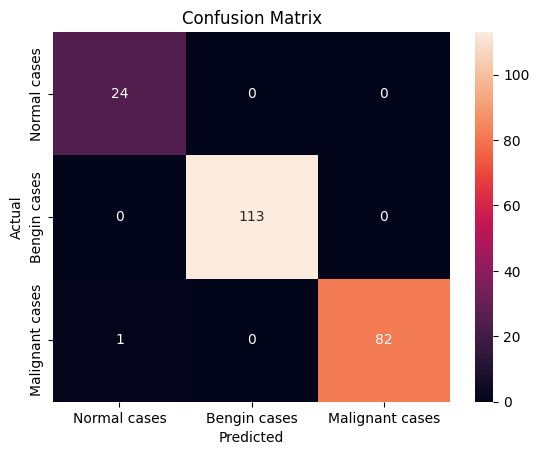

In [ ]:
# Predictions
y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

# Confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', xticklabels=classes, yticklabels=classes)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


In [ ]:
# Classification Report
report = classification_report(y_true, y_pred, target_names=classes)
print(report)


                 precision    recall  f1-score   support

   Normal cases       0.96      1.00      0.98        24
   Bengin cases       1.00      1.00      1.00       113
Malignant cases       1.00      0.99      0.99        83

       accuracy                           1.00       220
      macro avg       0.99      1.00      0.99       220
   weighted avg       1.00      1.00      1.00       220



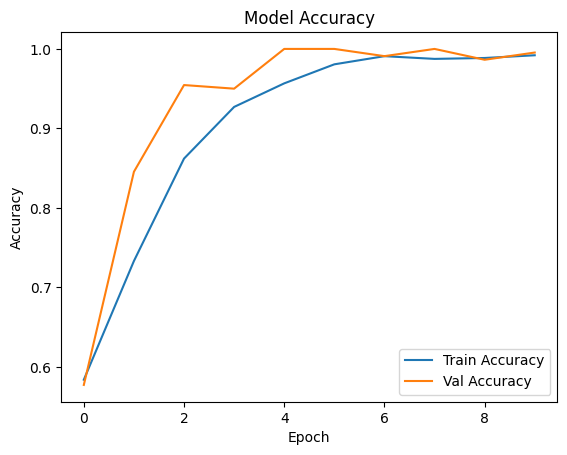

In [ ]:
# Accuracy / Loss Plot
plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Val Accuracy")

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()


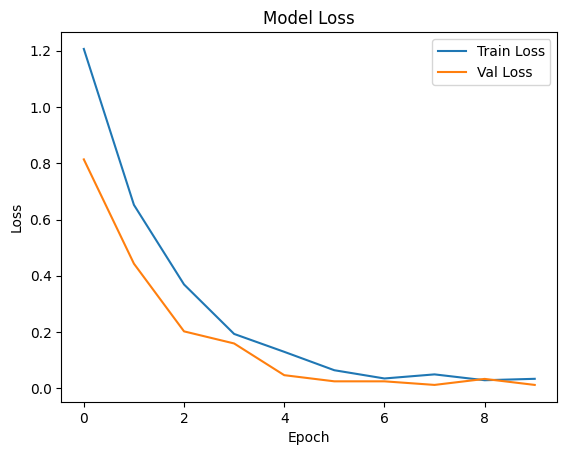

In [ ]:
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()
